In [12]:
#creates fake synthetic data
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

In [14]:
import matplotlib.pyplot as plt

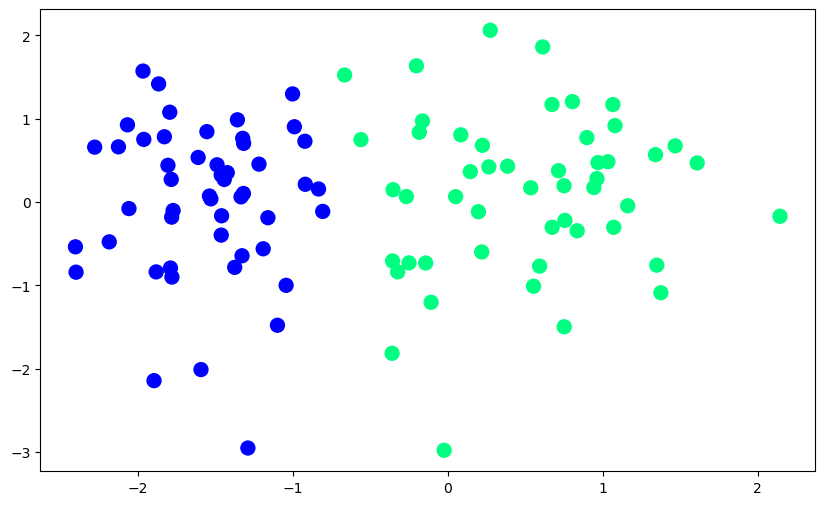

In [15]:
#x[:,0] denotes all values of feature 1 and x[:,1]denotes all values of feature 2
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [16]:
def perceptron(X,y):
    #insert columns of 1s at beginning
    X = np.insert(X,0,1,axis=1)
    #weights=[1,1,1]
    weights = np.ones(X.shape[1])
    #learning rate
    lr = 0.1
    
    for i in range(1000):
        #Randomly select one data point
        j = np.random.randint(0,100)
        #our prediction
        y_hat = step(np.dot(X[j],weights))
        #New weight = Old weight + correction
        weights = weights + lr*(y[j]-y_hat)*X[j]
    #Returns:weights[0] → bias and weights[1:] → actual feature weights  
    return weights[0],weights[1:]

In [17]:
def step(z):
    return 1 if z>0 else 0

In [18]:
intercept_,coef_ = perceptron(X,y)

In [19]:
#print w0,w1,w2
print(coef_)
print(intercept_)

[1.40692206 0.10479561]
0.8


In [20]:
#This converts equation into: x2 = m*x1 + b
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [21]:
#Creates 100 x-values between -3 and 3
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

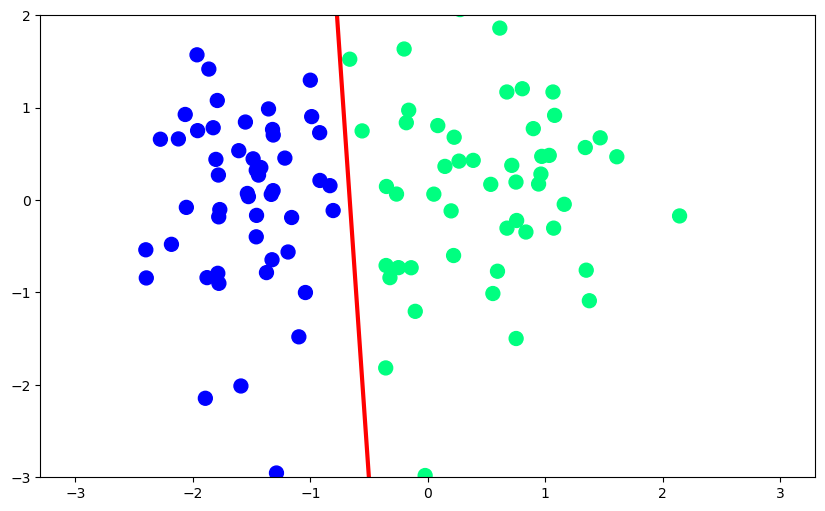

In [ ]:
plt.figure(figsize=(10,6))
#Draws the decision boundary line
plt.plot(x_input,y_input,color='red',linewidth=3)
#Plots our data points (same as before)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
#Adjusts y-axis range
plt.ylim(-3,2)